In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('WELFake_Dataset.csv')
print("Shape :", df.shape)
print("First 5 rows :")
df.head()

Shape : (72134, 4)
First 5 rows :


,Unnamed: 0,title,text,label
0,0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,1,NaN,Did they post their votes for Hillary already?,1
2,2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1
3,3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1


In [3]:
print(df.dtypes)
print("\nColumns:", df.columns.tolist())

Unnamed: 0    int64
title           str
text            str
label         int64
dtype: object

Columns: ['Unnamed: 0', 'title', 'text', 'label']


In [4]:
print("Null values:\n", df.isnull().sum())

Null values:
 Unnamed: 0      0
title         558
text           39
label           0
dtype: int64


label
1    37106
0    35028
Name: count, dtype: int64


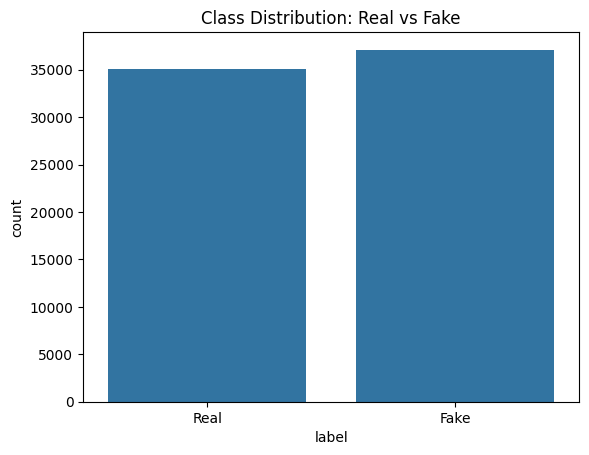

In [5]:
print(df['label'].value_counts())

sns.countplot(x='label', data=df)
plt.title('Class Distribution: Real vs Fake')
plt.xticks([0, 1], ['Real', 'Fake'])
plt.show()

In [6]:
print(df['text'].apply(type).value_counts())

text
<class 'str'>      72095
<class 'float'>       39
Name: count, dtype: int64


In [7]:
print(df['text'].isna().sum())

39


In [8]:
df = df.dropna(subset = ['text'])

In [9]:
print(df['text'].apply(type).value_counts())

text
<class 'str'>    72095
Name: count, dtype: int64


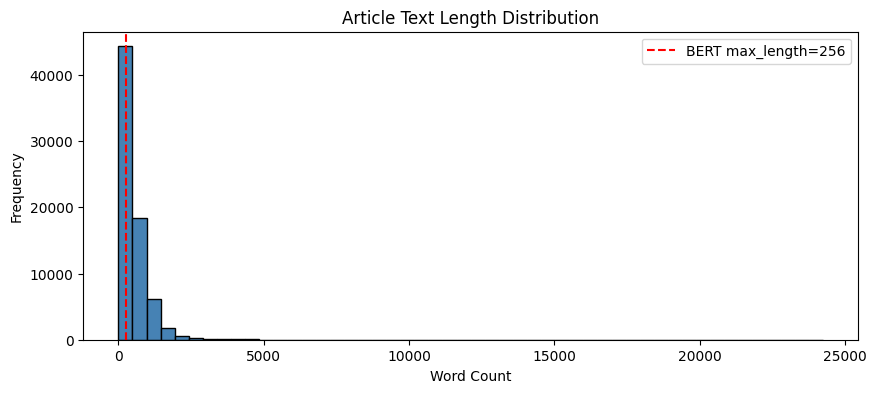

Average word count: 540.8
Max word count: 24234


In [10]:
df['text_length'] = df['text'].astype(str).apply(lambda x: len(x.split()))

plt.figure(figsize=(10, 4))
plt.hist(df['text_length'], bins=50, color='steelblue', edgecolor='black')
plt.title('Article Text Length Distribution')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.axvline(256, color='red', linestyle='--', label='BERT max_length=256')
plt.legend()
plt.show()

print("Average word count:", df['text_length'].mean().round(1))
print("Max word count:", df['text_length'].max())

In [13]:
df['content'] = (
    df['title'].astype(str)
    + ' '
    + df['text'].astype(str).apply(
        lambda x: ' '.join(x.split()[:500])
    )
)

In [14]:
print("Before:", df.shape)
df = df.dropna(subset=['text', 'title'])
print("After:", df.shape)

Before: (72095, 6)
After: (71537, 6)


In [15]:
df['content'] = (df['title'].astype(str) + ' ' + 
                 df['text'].astype(str).apply(lambda x: ' '.join(x.split()[:500])))

print("Sample content:\n", df['content'].iloc[0][:300])


Sample content:
 LAW ENFORCEMENT ON HIGH ALERT Following Threats Against Cops And Whites On 9-11By #BlackLivesMatter And #FYF911 Terrorists [VIDEO] No comment is expected from Barack Obama Members of the #FYF911 or #FukYoFlag and #BlackLivesMatter movements called for the lynching and hanging of white people and cop


In [16]:
import re

def clean_text(text):
    text = text.lower()                          # lowercase
    text = re.sub(r'http\S+', '', text)          # remove URLs
    text = re.sub(r'<.*?>', '', text)            # remove HTML tags
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)  # remove special characters
    text = re.sub(r'\s+', ' ', text).strip()     # remove extra spaces
    return text

df['content'] = df['content'].apply(clean_text)
print("Cleaned sample:\n", df['content'].iloc[0][:300])

Cleaned sample:
 law enforcement on high alert following threats against cops and whites on 911by blacklivesmatter and fyf911 terrorists video no comment is expected from barack obama members of the fyf911 or fukyoflag and blacklivesmatter movements called for the lynching and hanging of white people and cops they e


In [17]:
df = df[['content', 'label']].reset_index(drop=True)

print("Final shape:", df.shape)
print("Label distribution:\n", df['label'].value_counts())
print("\nSample:\n", df.head(3))

Final shape: (71537, 2)
Label distribution:
 label
1    36509
0    35028
Name: count, dtype: int64

Sample:
                                              content  label
0  law enforcement on high alert following threat...      1
1  unbelievable obamas attorney general says most...      1
2  bobby jindal raised hindu uses story of christ...      0


In [18]:
print("Duplicate rows:", df.duplicated(subset=['content']).sum())
df = df.drop_duplicates(subset=['content']).reset_index(drop=True)
print("Shape after removing duplicates:", df.shape)

Duplicate rows: 8466
Shape after removing duplicates: (63071, 2)


In [19]:
print(df['label'].value_counts())
print(df['label'].value_counts(normalize=True) * 100)

label
0    34766
1    28305
Name: count, dtype: int64
label
0    55.122005
1    44.877995
Name: proportion, dtype: float64


In [20]:
df.to_csv('cleaned_welface.csv', index=False)
print("Saved successfully.")

Saved successfully.
